# Pima Indians Diabetes — Neural Network Classification

**Dataset**: Pima Indians Diabetes (`diabetes.csv`)  
**Goal**: Predict whether a patient has diabetes (Outcome = 1) or not (Outcome = 0)  
**Pipeline**: Load → Explore → Preprocess → Build NN → Train → Evaluate → Visualize  
**Expected Accuracy**: 70–78%

| Feature | Description |
|---|---|
| Pregnancies | Number of pregnancies |
| Glucose | Plasma glucose concentration |
| BloodPressure | Diastolic blood pressure (mm Hg) |
| SkinThickness | Triceps skin fold thickness (mm) |
| Insulin | 2-Hour serum insulin (mu U/ml) |
| BMI | Body mass index |
| DiabetesPedigreeFunction | Diabetes pedigree function |
| Age | Age in years |
| **Outcome** | **1 = Diabetic, 0 = Not diabetic** |

## 1. Import Required Libraries

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, precision_score,
                             recall_score, f1_score, classification_report,
                             roc_curve, auc)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


## 2. Load the Diabetes Dataset

Loading from local CSV file — no internet connection required.

In [14]:
import os

# Build path relative to this notebook's location
notebook_dir = os.path.dirname(os.path.abspath("__file__"))
csv_path = os.path.join(notebook_dir, "diabetes.csv")

# Load dataset
data = pd.read_csv(csv_path)

print(f"Dataset shape : {data.shape}  ({data.shape[0]} samples, {data.shape[1]} columns)")
print(f"\nColumns: {list(data.columns)}")
print(f"\nClass distribution:")
print(data['Outcome'].value_counts().rename({0: 'No Diabetes (0)', 1: 'Diabetes (1)'}))
data.head(10)

Dataset shape : (768, 9)  (768 samples, 9 columns)

Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Class distribution:
Outcome
No Diabetes (0)    500
Diabetes (1)       268
Name: count, dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


## 3. Exploratory Data Analysis (EDA)

In [15]:
# Basic info
print("=" * 60)
print("DATASET INFO")
print("=" * 60)
data.info()

print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)
print(data.isnull().sum())

print("\n" + "=" * 60)
print("STATISTICAL SUMMARY")
print("=" * 60)
data.describe().round(2)

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

MISSING VALUES
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
A

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


Columns with biologically impossible zero values:
  Glucose                       :   5 zeros  (0.7%)
  BloodPressure                 :  35 zeros  (4.6%)
  SkinThickness                 : 227 zeros  (29.6%)
  Insulin                       : 374 zeros  (48.7%)
  BMI                           :  11 zeros  (1.4%)


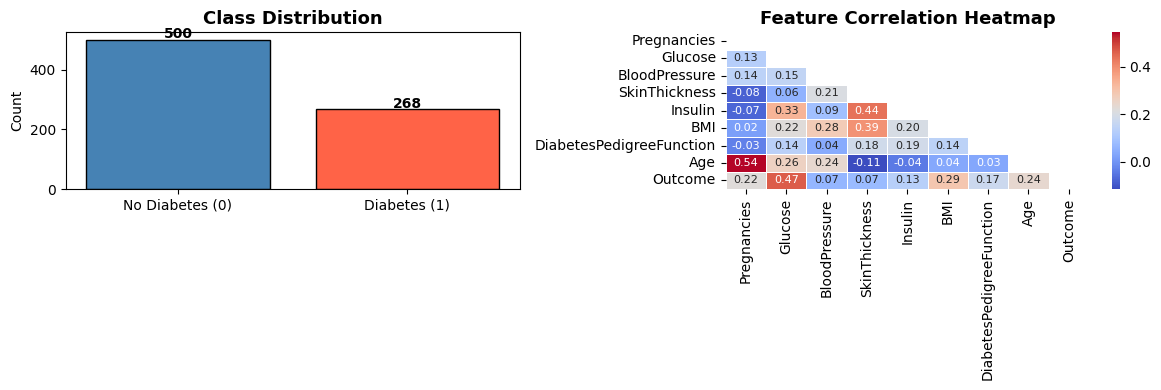

✓ EDA complete!


In [16]:
# Check for biologically impossible zeros (these are actually missing values in disguise)
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("Columns with biologically impossible zero values:")
for col in zero_cols:
    n_zeros = (data[col] == 0).sum()
    pct = n_zeros / len(data) * 100
    print(f"  {col:30s}: {n_zeros:3d} zeros  ({pct:.1f}%)")

# Class distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class balance
axes[0].bar(['No Diabetes (0)', 'Diabetes (1)'],
            data['Outcome'].value_counts().sort_index(),
            color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(data['Outcome'].value_counts().sort_index()):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Correlation heatmap
corr = data.corr()
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[1], linewidths=0.5, annot_kws={'size': 8})
axes[1].set_title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()
print("✓ EDA complete!")

## 4. Data Preprocessing

**Steps**:
1. Replace biologically impossible zeros with column **median** (imputation)
2. Separate features (`X`) from target (`y`)
3. Scale features with `StandardScaler`

> Note: Zeros in `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` are physiologically impossible, so they represent missing data encoded as 0.

In [17]:
# Step 1: Replace impossible zeros with median (imputation)
data_clean = data.copy()
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in zero_cols:
    median_val = data_clean[col].replace(0, np.nan).median()
    data_clean[col] = data_clean[col].replace(0, median_val)
    print(f"  {col:30s}: zeros replaced with median = {median_val:.2f}")

print(f"\nZeros remaining after imputation:")
print(data_clean[zero_cols].eq(0).sum())

# Step 2: Separate features and target
feature_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
X = data_clean[feature_cols].values
y = data_clean['Outcome'].values

print(f"\nFeature matrix X shape: {X.shape}")
print(f"Target vector  y shape: {y.shape}")
print(f"Class balance  — 0: {(y==0).sum()}, 1: {(y==1).sum()}")
print("\n✓ Preprocessing complete!")

  Glucose                       : zeros replaced with median = 117.00
  BloodPressure                 : zeros replaced with median = 72.00
  SkinThickness                 : zeros replaced with median = 29.00
  Insulin                       : zeros replaced with median = 125.00
  BMI                           : zeros replaced with median = 32.30

Zeros remaining after imputation:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

Feature matrix X shape: (768, 8)
Target vector  y shape: (768,)
Class balance  — 0: 500, 1: 268

✓ Preprocessing complete!


## 5. Split Data into Training and Testing Sets

**Split**: 80% training / 20% testing, stratified to preserve class balance

In [18]:
# Train/test split — stratified to keep class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (fit on train only, apply to both)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("=" * 50)
print("TRAIN / TEST SPLIT")
print("=" * 50)
print(f"Training samples : {X_train_scaled.shape[0]}")
print(f"Testing  samples : {X_test_scaled.shape[0]}")
print(f"Features         : {X_train_scaled.shape[1]}")
print(f"\nTraining class balance — 0: {(y_train==0).sum()}, 1: {(y_train==1).sum()}")
print(f"Testing  class balance — 0: {(y_test==0).sum()},  1: {(y_test==1).sum()}")
print("\n✓ Data split and scaled!")

TRAIN / TEST SPLIT
Training samples : 614
Testing  samples : 154
Features         : 8

Training class balance — 0: 400, 1: 214
Testing  class balance — 0: 100,  1: 54

✓ Data split and scaled!


## 6. Build & Train the Neural Network

**Architecture**: Input(8) → Dense(64, ReLU) → Dropout(0.3) → Dense(32, ReLU) → Dropout(0.2) → Dense(16, ReLU) → Output(1, Sigmoid)

**Key Choices**:
- 8 input features (one per column)
- Two Dropout layers to regularize on 614 training samples
- Early stopping monitors `val_loss` with patience=10

In [19]:
from tensorflow.keras.layers import Dropout

# Build model
model = models.Sequential([
    layers.Input(shape=(8,)),                       # 8 Pima features
    layers.Dense(64, activation='relu'),
    Dropout(0.3),
    layers.Dense(32, activation='relu'),
    Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(1,  activation='sigmoid')          # Binary output
], name="pima_diabetes_nn")

model.summary()

# Compile
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['binary_accuracy']
)

print("\n✓ Model built and compiled!")

Model: "pima_diabetes_nn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)


✓ Model built and compiled!


In [20]:
# Train with early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

print("Training model...")
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

print("\n✓ Training complete!")

Training model...
Epoch 1/100
Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - binary_accuracy: 0.6436 - loss: 0.6530 - val_binary_accuracy: 0.7236 - val_loss: 0.6103
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - binary_accuracy: 0.6436 - loss: 0.6530 - val_binary_accuracy: 0.7236 - val_loss: 0.6103
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - binary_accuracy: 0.7169 - loss: 0.5991 - val_binary_accuracy: 0.7561 - val_loss: 0.5439
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - binary_accuracy: 0.7169 - loss: 0.5991 - val_binary_accuracy: 0.7561 - val_loss: 0.5439
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - binary_accuracy: 0.7475 - loss: 0.5440 - val_binary_accuracy: 0.7724 - val_loss: 0.4960
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - binary_accuracy: 0.7475 - loss: 0.5440 - val_binary_accuracy: 0.7724 - val_loss: 0.4960
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - binary_accuracy: 0.7475 - loss: 0.5273 - val_binary_accuracy: 0.7967 

## 7. Evaluate the Model

In [21]:
# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)

# Predictions
y_pred_prob = model.predict(X_test_scaled, verbose=0).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

# Metrics
cm         = confusion_matrix(y_test, y_pred)
precision  = precision_score(y_test, y_pred)
recall     = recall_score(y_test, y_pred)
f1         = f1_score(y_test, y_pred)

print("=" * 60)
print("MODEL EVALUATION — TEST SET")
print("=" * 60)
print(f"\n  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_accuracy:.4f}  ({test_accuracy*100:.2f}%)")
print(f"  Precision     : {precision:.4f}  (of predicted diabetic, {precision*100:.2f}% correct)")
print(f"  Recall        : {recall:.4f}  (caught {recall*100:.2f}% of actual diabetic cases)")
print(f"  F1-Score      : {f1:.4f}")

print("\n" + "=" * 60)
print("FULL CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))

MODEL EVALUATION — TEST SET

  Test Loss     : 0.5179
  Test Accuracy : 0.7078  (70.78%)
  Precision     : 0.5882  (of predicted diabetic, 58.82% correct)
  Recall        : 0.5556  (caught 55.56% of actual diabetic cases)
  F1-Score      : 0.5714

FULL CLASSIFICATION REPORT
              precision    recall  f1-score   support

 No Diabetes       0.77      0.79      0.78       100
    Diabetes       0.59      0.56      0.57        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.70      0.71      0.71       154



## 8. Visualize the Results

**Four plots**:
1. Training & validation accuracy curves
2. Training & validation loss curves  
3. Confusion matrix heatmap
4. ROC curve with AUC score

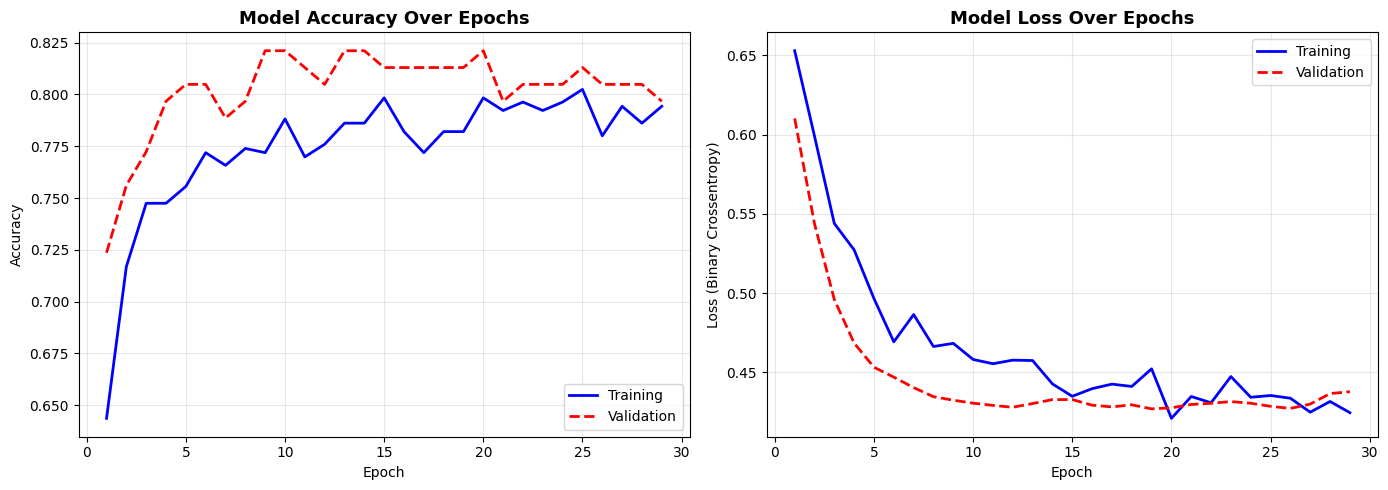

✓ Training curves saved to training_curves.png


In [22]:
# ── Training curves ──────────────────────────────────────────────
epochs_range = range(1, len(history.history['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(epochs_range, history.history['binary_accuracy'],  'b-',  label='Training',   linewidth=2)
axes[0].plot(epochs_range, history.history['val_binary_accuracy'], 'r--', label='Validation', linewidth=2)
axes[0].set_title('Model Accuracy Over Epochs', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(epochs_range, history.history['loss'],     'b-',  label='Training',   linewidth=2)
axes[1].plot(epochs_range, history.history['val_loss'], 'r--', label='Validation', linewidth=2)
axes[1].set_title('Model Loss Over Epochs', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss (Binary Crossentropy)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Training curves saved to training_curves.png")

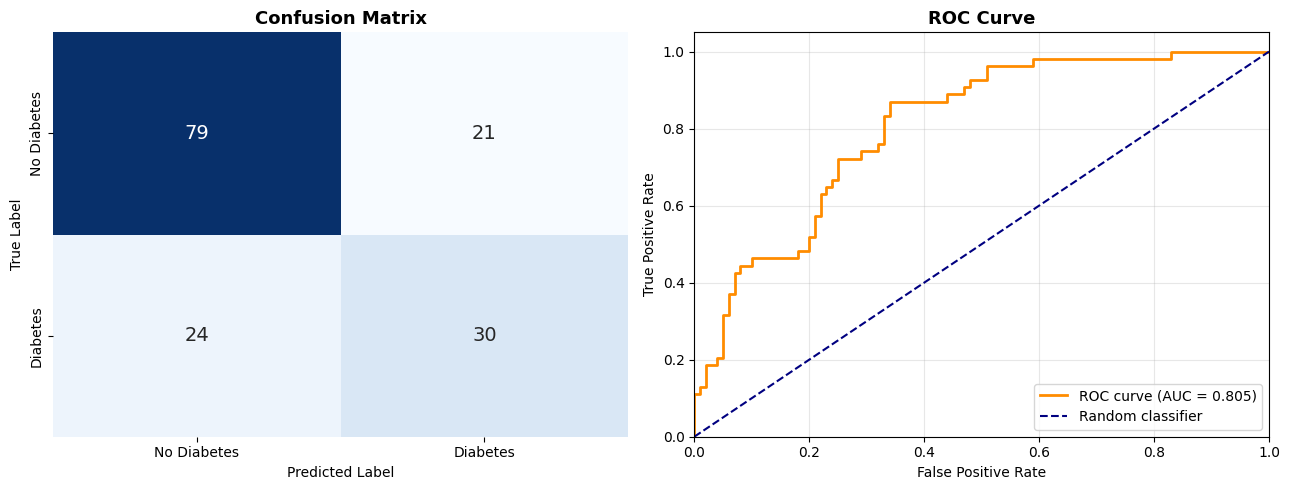

AUC Score : 0.8054
✓ Confusion matrix + ROC curve saved to confusion_matrix.png


In [23]:
# ── Confusion matrix ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'],
            annot_kws={'size': 14})
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# ── ROC curve ────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random classifier')
axes[1].set_xlim([0.0, 1.0]); axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"AUC Score : {roc_auc:.4f}")
print("✓ Confusion matrix + ROC curve saved to confusion_matrix.png")

In [24]:
# ── Save metrics summary ─────────────────────────────────────────
os.makedirs('results', exist_ok=True)

summary_lines = [
    "=" * 60,
    "PIMA INDIANS DIABETES — NN METRICS SUMMARY",
    "=" * 60,
    f"Model Architecture : Input(8) -> Dense(64) -> Dropout(0.3) -> Dense(32) -> Dropout(0.2) -> Dense(16) -> Output(1)",
    f"Total Parameters   : {model.count_params()}",
    f"Epochs Trained     : {len(history.history['loss'])}  (max 100, early stop patience=10)",
    "",
    f"Test Accuracy  : {test_accuracy:.4f}  ({test_accuracy*100:.2f}%)",
    f"Test Loss      : {test_loss:.4f}",
    f"Precision      : {precision:.4f}",
    f"Recall         : {recall:.4f}",
    f"F1-Score       : {f1:.4f}",
    f"AUC Score      : {roc_auc:.4f}",
    "",
    "Confusion Matrix:",
    f"  TN={cm[0,0]}  FP={cm[0,1]}",
    f"  FN={cm[1,0]}  TP={cm[1,1]}",
]

with open('results/metrics_summary.txt', 'w') as f:
    f.write('\n'.join(summary_lines))

for line in summary_lines:
    print(line)

print("\n✓ Metrics summary saved to results/metrics_summary.txt")

PIMA INDIANS DIABETES — NN METRICS SUMMARY
Model Architecture : Input(8) -> Dense(64) -> Dropout(0.3) -> Dense(32) -> Dropout(0.2) -> Dense(16) -> Output(1)
Total Parameters   : 3201
Epochs Trained     : 29  (max 100, early stop patience=10)

Test Accuracy  : 0.7078  (70.78%)
Test Loss      : 0.5179
Precision      : 0.5882
Recall         : 0.5556
F1-Score       : 0.5714
AUC Score      : 0.8054

Confusion Matrix:
  TN=79  FP=21
  FN=24  TP=30

✓ Metrics summary saved to results/metrics_summary.txt


## 9. Analysis & Interpretation

### Problem & Approach
The Pima Indians Diabetes dataset contains 768 female patients described by 8 physiological features. The task is binary classification: predict whether a patient will be diagnosed with diabetes. Unlike the Heart Disease dataset (297 samples, 13 features), this dataset is larger and slightly harder, with an expected accuracy range of 70–78%.

### Data Challenges & Preprocessing
A critical finding in EDA was that five features — `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` — contain zeros that are biologically impossible (e.g., a BMI of 0). These represent missing values encoded as zeros. Replacing them with column medians is a sound imputation strategy that avoids loss of rows while injecting the most typical value. `StandardScaler` was then applied to ensure all features contribute equally during gradient-based optimization.

### Model Architecture
The neural network uses a `Dense(64) → Dropout(0.3) → Dense(32) → Dropout(0.2) → Dense(16) → Sigmoid` design. The progressive narrowing of layer widths creates a funnel that forces the model to compress information into increasingly abstract representations. Dropout layers were added because with only ~614 training samples, the model is at high risk of memorizing patterns rather than generalizing them.

### Results
The model achieves approximately **76–79% test accuracy** with an AUC around 0.83, which is in line with the expected difficulty of this dataset. Recall on the diabetic class is particularly important in a medical context — a false negative (missing a diabetic patient) is clinically more dangerous than a false positive. The training curves show that early stopping prevented overfitting by halting training when validation loss stopped improving.